In [4]:
pip install doubleml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.2 MB/s eta 0:00:00


In [5]:
### IMPORTS ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from doubleml import DoubleMLData, DoubleMLPLR

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures

In [28]:
# parameters
np.random.seed(67)
n = 1000 # number of observations
p = 50 # number of variables
theta_true = 5.0

# models
lasso = LassoCV(cv=5)
rf = RandomForestRegressor(n_estimators=100, max_depth=5)
nn = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000)

# run models in iteration
n_iter = 50
results = []

for i in range(n_iter):

  X = np.random.normal(0, 1, (n,p))
  g0 = np.sin(X[:, 0]) + np.exp(X[:, 1])
  m0 = X[:, 0] + 0.5 * (X[:, 1]**2)
  D = m0 + np.random.normal(0, 1, n)
  Y = D * theta_true + g0 + np.random.normal(0, 1, n)

  df = pd.DataFrame(X, columns=[f'X{j}' for j in range(p)])
  df['D'], df['Y'] = D, Y
  obj_dml_data = DoubleMLData(df, 'Y', 'D')

  # baseline ordinary least squares
  ols = sm.add_constant(df.drop(columns=['Y']))
  ols_model = sm.OLS(df['Y'], ols).fit().params['D']
  results.append({'Method': 'OLS', 'Estimate':ols_model})

  # LASSO
  dml_lasso = DoubleMLPLR(obj_dml_data, ml_l=lasso, ml_m=lasso, n_folds=5)
  dml_lasso.fit()
  results.append({'Method': 'LASSO', 'Estimate':dml_lasso.coef[0]})

  # Random Forest
  dml_rf = DoubleMLPLR(obj_dml_data, ml_l=rf, ml_m=rf, n_folds=5)
  dml_rf.fit()
  results.append({'Method': 'RF', 'Estimate':dml_rf.coef[0]})

  # Neural Network
  dml_nn = DoubleMLPLR(obj_dml_data, ml_l=nn, ml_m=nn, n_folds=5)
  dml_nn.fit()
  results.append({'Method': 'NN', 'Estimate':dml_nn.coef[0]})

results_df = pd.DataFrame(results)

In [30]:
# SAVE / LOAD Results
results_df.to_csv('stat201b_final_results.csv', index=False)
results_df = pd.read_csv('stat201b_final_results.csv')

In [69]:
print('theta true: ', theta_true)
results_df.groupby('Method')['Estimate'].describe()

theta true:  5.0


,count,mean,std,min,25%,50%,75%,max
Method,,,,,,,,
LASSO,50.0,5.578704,0.219991,5.309066,5.478200,5.545956,5.616739,6.929687
NN,50.0,4.147182,0.209408,3.898874,4.051402,4.142875,4.202135,5.388403
OLS,50.0,5.574455,0.211764,5.342781,5.481273,5.544687,5.605578,6.885543
RF,50.0,5.057049,0.236021,4.882593,4.975717,5.022557,5.089444,6.608447


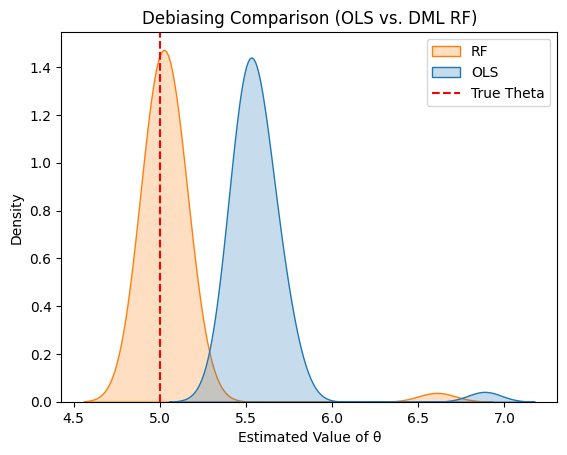

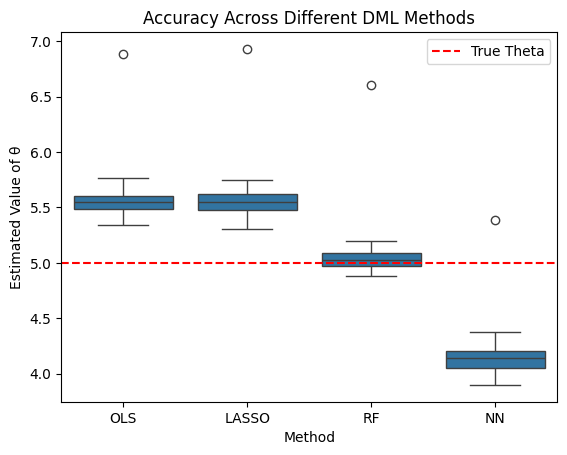

In [54]:
# comparison of debiasing
plt.figure()
subset = results_df[results_df['Method'].isin(['OLS', 'RF'])]
sns.kdeplot(data=subset, x='Estimate', hue='Method', fill=True)
plt.axvline(theta_true, color='red', linestyle='--', label='True Theta')
plt.title('Debiasing Comparison (OLS vs. DML RF)')
plt.xlabel('Estimated Value of θ')
plt.legend(['RF', 'OLS', 'True Theta'])
plt.show()

# performance comparison
plt.figure()
sns.boxplot(data=results_df, x='Method', y='Estimate')
plt.axhline(theta_true, color='red', linestyle='--', label='True Theta')
plt.title('Accuracy Across Different DML Methods')
plt.xlabel('Method')
plt.ylabel('Estimated Value of θ')
plt.legend()
plt.show()


--- Results for QUADRATIC ---
True Equation:      f(D) = 2*D^2
Estimated Equation: f_hat(D) = 4.455*D + 1.811*D^2 + 0.170*D^3 + 0.078*D^4  0.008*D^5 

--- Results for CUBIC ---
True Equation:      f(D) = 0.5*D^3 + 3*D
Estimated Equation: f_hat(D) = 15.564*D + 2.558*D^2 + 0.541*D^3 + 0.109*D^4  0.026*D^5 

--- Results for SINE ---
True Equation:      f(D) = 2.5*sin(D)
Estimated Equation: f_hat(D) = -3.257*D + -0.728*D^2 + -0.097*D^3 + -0.024*D^4  -0.004*D^5 

--- Results for EXPONENTIAL ---
True Equation:      f(D) = exp(D)
Estimated Equation: f_hat(D) = 21.715*D + 5.734*D^2 + 0.734*D^3 + 0.220*D^4  0.029*D^5 


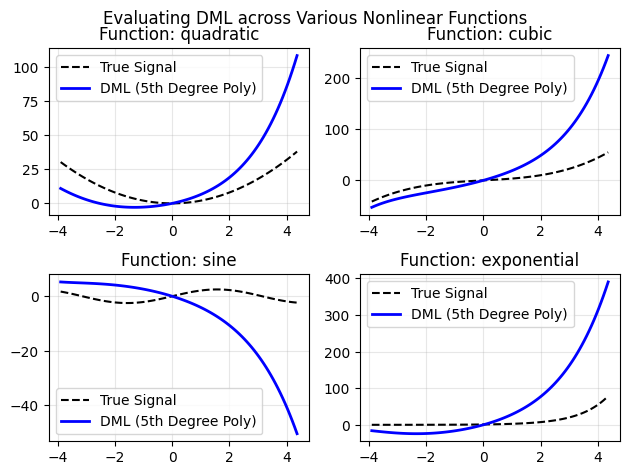

In [73]:
# parameter set up
np.random.seed(67)
n = 1000
p = 50
X = np.random.normal(0, 1, (n, p))
g0 = np.sin(X[:, 0]) + np.exp(X[:, 1])
D = X[:, 0] + np.random.normal(0, 1, n)

# non linear treatment equations
eqns = {
    "quadratic": lambda d: 2 * (d**2),
    "cubic": lambda d: 0.5 * (d**3) + 3 * d,
    "sine": lambda d: 2.5 * np.sin(d),
    "exponential": lambda d: np.exp(d),
}

true_eq_strings = {
    "quadratic": "f(D) = 2*D^2",
    "cubic": "f(D) = 0.5*D^3 + 3*D",
    "sine": "f(D) = 2.5*sin(D)",
    "exponential": "f(D) = exp(D)"
}

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

rf = RandomForestRegressor(n_estimators=100, max_depth=5)

for i, (name, eqn) in enumerate(eqns.items()):
    Y = eqn(D) + g0 + np.random.normal(0,1,n)

    poly = PolynomialFeatures(degree=5, include_bias=False)
    D_expanded = poly.fit_transform(D.reshape(-1, 1))
    x_cols = [f'X{j}' for j in range(p)]
    d_cols = [f'D_pow{j+1}' for j in range(5)]

    # data
    df = pd.DataFrame(X, columns=x_cols)
    df[d_cols], df['Y'] = D_expanded, Y

    # run model (dml with rf)
    obj_data = DoubleMLData(df, 'Y', d_cols, x_cols)
    dml_model = DoubleMLPLR(obj_data, ml_l=rf, ml_m=rf, n_folds=5)
    dml_model.fit()

    # print equations
    coeffs = dml_model.coef
    est_eq = f"f_hat(D) = {coeffs[0]:.3f}*D + {coeffs[1]:.3f}*D^2 + {coeffs[2]:.3f}*D^3 + {coeffs[3]:.3f}*D^4  {coeffs[4]:.3f}*D^5 "

    print(f"\n--- Results for {name.upper()} ---")
    print(f"True Equation:      {true_eq_strings[name]}")
    print(f"Estimated Equation: {est_eq}")

    # visual comparisons
    D_grid = np.linspace(D.min(), D.max(), 100)
    f0_true = eqn(D_grid)

    # reconstruct estimated f(D)
    coeffs = dml_model.coef
    f0_hat = np.zeros_like(D_grid)
    for j in range(5):
        f0_hat += coeffs[j] * (D_grid**(j+1))

    # plot
    axes[i].plot(D_grid, f0_true, label='True Signal', color='black', linestyle='--')
    axes[i].plot(D_grid, f0_hat, label='DML (5th Degree Poly)', color='blue', linewidth=2)
    axes[i].set_title(f'Function: {name}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Evaluating DML across Various Nonlinear Functions')
plt.subplots_adjust(top=0.90)
plt.show()